<a href="https://colab.research.google.com/github/suganthavk-ai/-Social-Media-Engagement-Analysis/blob/main/Social_Media_Engagement_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📊 Social Media Engagement Analysis**

**Dataset Provided:**
social_media_engagement_5000.csv

# **Task 1 — Data Import & Setup**

1.1 Import CSV using Pandas

1.2 Check/convert data types

1.3 Convert date columns to datetime


In [19]:
!pip install matplotlib seaborn plotly.express pandas numpy

In [20]:
# Data Import & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [21]:
# Load CSV file
#https://github.com/GeethaGunasekaran1/Dataset_rep/blob/main/social_media_engagement_5000.csv

df=pd.read_csv("https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv")
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


# **Check dataset structure**

In [22]:
print("Shape:",df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Shape: (5000, 19)

Columns:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']

Data Types:
user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Nu

In [23]:
# Check missing values

df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


# **Task 2 — Data Cleaning**



**2.1 Cleaning Missing Data**

■ Detect missing values (isnull(), isna())

■ Handle using: dropna(), fillna(), median/mode, forward/backward-fill

**2.2 Duplicate Handling**

Identify & remove duplicates

**2.3 Data Formatting**

■ Fix incorrect data types

■ Standardize categories (e.g., gender labels)

■ Correct unrealistic values in likes, comments, shares

**2.4 Feature Cleaning**

■ Extract hashtag count

■ Clean sentiment labels

In [24]:
# Total missing Values

print(df.isnull().sum())

#Total missing values in entire dataset
print("Total Missing Values: ",df.isnull().sum().sum())

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64
Total Missing Values:  900


In [25]:
from pandas.core.arrays import categorical
# Handle Missing Values by identifing numeric and category columns:

numeric_colm = df.select_dtypes(include=np.number).columns
categorical_colm = df.select_dtypes(include="object").columns

print("Numeric Columns: ")
print(numeric_colm)

print("\nCategorical Columns: ")
print(categorical_colm)


Numeric Columns: 
Index(['user_id', 'age', 'post_id', 'likes', 'comments', 'shares',
       'watch_time_sec', 'impression_count', 'follower_count',
       'engagement_rate'],
      dtype='object')

Categorical Columns: 
Index(['gender', 'country', 'post_type', 'post_category', 'posted_at',
       'device_type', 'sentiment', 'hashtags'],
      dtype='object')


In [26]:
# Fill numeric missing values with median
for col in numeric_colm:
    df[col] = df[col].fillna(df[col].median())


In [27]:
# Fill categorical missing values with mode

for col in categorical_colm:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()


,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [28]:
# Duplicate handling
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())
# Remove duplicates:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Duplicate rows: 0
Shape after removing duplicates: (5000, 19)


In [29]:
# Data Formatting
# Convert date column

for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].unique())




 gender
['Female' 'Male' 'Other']

 country
['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']

 post_type
['image' 'reel' 'text' 'video']

 post_category
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']

 posted_at
['17-12-2022' '02-06-2023' '07-05-2023' '12-02-2023' '23-05-2023'
 '16-09-2023' '15-04-2022' '20-12-2023' '06-07-2023' '16-11-2022'
 '15-02-2022' '29-08-2022' '27-09-2022' '29-10-2023' '20-09-2023'
 '06-02-2022' '24-07-2022' '01-05-2023' '20-04-2022' '14-11-2022'
 '15-08-2023' '17-03-2022' '02-09-2023' '13-05-2023' '24-04-2023'
 '24-01-2023' '11-08-2023' '16-08-2023' '30-12-2022' '05-11-2022'
 '04-03-2022' '24-09-2022' '02-02-2022' '09-02-2022' '17-11-2023'
 '17-09-2022' '23-10-2023' '13-08-2022' '18-01-2023' '01-10-2023'
 '05-01-2022' '22-03-2023' '15-10-2022' '27-02-2022' '13-03-2022'
 '11-11-2023' '25-06-2023' '23-03-2022' '10-09-2023' '04-10-2022'
 '06-06-2023' '28-07-2023' '16-05-2022' '24-04-2022' '06-06-

In [30]:
df["gender"] = df["gender"].astype(str).str.strip().str.lower()

df["gender"] = df["gender"].replace({
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female"
})
# Check:
df["gender"].value_counts()


,count
gender,
Male,1849
other,1581
Female,1570


In [31]:
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()

df["sentiment"] = df["sentiment"].replace({
    "positive": "Positive",
    "negative": "Negative",
    "neutral": "Neutral"
})
# Check:
df["sentiment"].value_counts()


,count
sentiment,
Positive,2513
Neutral,1527
Negative,960


In [32]:
# Correct unrealistic engagement values
# For metrics such as likes, comments and shares, negative values are unrealistic.
engagement_cols = ["likes", "comments", "shares"]

for col in engagement_cols:
    df.loc[df[col] < 0, col] = np.nan
    df[col] = df[col].fillna(df[col].median())
# Check:
df[engagement_cols].describe()


,likes,comments,shares
count,5000.000000,5000.000000,5000.0000
mean,10106.997400,1502.039800,1002.9106
std,5702.293017,856.393312,570.8552
min,10.000000,0.000000,0.0000
25%,5235.000000,792.000000,511.0000
50%,10105.500000,1497.000000,1012.0000
75%,14959.000000,2235.250000,1483.0000
max,19998.000000,2999.000000,1999.0000


In [33]:
#['user_id', 'age', 'post_id', 'likes', 'comments', 'shares','watch_time_sec', 'impression_count', 'follower_count','engagement_rate]
engagement_cols1 = ['user_id', 'age', 'post_id',"likes", "comments", "shares",'watch_time_sec', 'impression_count', 'follower_count','engagement_rate']

for col in engagement_cols1:
    df.loc[df[col] < 0, col] = np.nan
    df[col] = df[col].fillna(df[col].median())
# Check:
df[engagement_cols1].describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,393698.224800,0.964356
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,230927.884535,5.318029
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,799533.000000,191.504348


In [34]:
# Find outliers using IQR method

columns = [
    "user_id",
    "age",
    "post_id",
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "impression_count",
    "follower_count",
    "engagement_rate"
]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\n{col}")
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


user_id
Lower Bound: -34997.0
Upper Bound: 144487.0
Number of Outliers: 0

age
Lower Bound: -11.5
Upper Bound: 88.5
Number of Outliers: 0

post_id
Lower Bound: -351003.0
Upper Bound: 1445121.0
Number of Outliers: 0

likes
Lower Bound: -9351.0
Upper Bound: 29545.0
Number of Outliers: 0

comments
Lower Bound: -1372.875
Upper Bound: 4400.125
Number of Outliers: 0

shares
Lower Bound: -947.0
Upper Bound: 2941.0
Number of Outliers: 0

watch_time_sec
Lower Bound: -3986.0
Upper Bound: 12024.0
Number of Outliers: 0

impression_count
Lower Bound: -49522.75
Upper Bound: 149173.25
Number of Outliers: 0

follower_count
Lower Bound: -398416.375
Upper Bound: 1182640.625
Number of Outliers: 0

engagement_rate
Lower Bound: -0.3927378342499999
Upper Bound: 1.04331262375
Number of Outliers: 578


In [35]:
df["engagement_rate"].sort_values(ascending=False).head(10)

,engagement_rate
554,191.504348
144,121.931973
1947,105.752212
541,92.828829
145,87.266094
4181,77.160173
2369,68.685897
2426,67.511041
652,65.580247
2993,61.179775


Outlier Detection: The IQR method was applied to the numerical variables. No significant outliers were detected in user_id, age, post_id, likes, comments, shares, watch_time_sec, impression_count, or follower_count. However, engagement_rate contains statistical outliers that require further investigation for possible data-quality or calculation issues.

# 2.5 Feature Cleaning — Hashtag Count

In [36]:
# If your dataset has a hashtags column:
def count_hashtags(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

df["hashtag_count"] = df["hashtags"].apply(count_hashtags)
# If hashtags are stored like:
# travel #india #vacation
# the result will be:
# 3
# Check:
df[["hashtags", "hashtag_count"]].head()


,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


# **Task 3 — Data Exploration using Pandas**

Perform the following:

3.1 View dataset structure using head(), tail(), shape, and columns.

3.2 Check data types and info with info() and dtypes.

3.3 Generate summary statistics using describe().

3.4 Analyze categorical distributions using value_counts(), unique(), and nunique().

3.5 Create a correlation matrix for numeric fields.

3.6 Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).


# 3.1 View dataset structure using head(), tail(), shape, and columns.

In [37]:
# Head
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795.0,43.0,Female,Brazil,496713.0,image,fitness,7011.0,354.0,1157.0,5726.0,44650.0,17-12-2022,81734.0,False,mobile,Negative,#foodie #travel #love,0.190862,3
1,10860.0,33.0,Male,Brazil,157326.0,reel,food,11750.0,2606.0,1807.0,5947.0,80216.0,02-06-2023,5963.0,False,mobile,Negative,#fitness,0.201493,1
2,86820.0,32.0,Female,UK,109864.0,text,food,4862.0,344.0,955.0,6946.0,44858.0,07-05-2023,501783.0,False,tablet,Positive,#foodie,0.137345,1
3,64886.0,51.0,other,France,848877.0,text,fitness,5350.0,1083.0,1049.0,229.0,70455.0,12-02-2023,480212.0,False,mobile,Negative,#music #foodie #fun,0.106195,3
4,16265.0,34.0,other,UK,449706.0,image,fitness,12682.0,2735.0,1300.0,4798.0,6019.0,23-05-2023,383936.0,False,mobile,Negative,#travel,2.777372,1


In [38]:
# Tail
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500.0,44.0,Male,Australia,441541.0,video,education,16210.0,2013.0,1837.0,6190.0,42977.0,25-06-2022,646147.0,False,mobile,Positive,#travel #fun,0.466761,2
4996,22100.0,38.0,other,UAE,677076.0,reel,education,16924.0,2734.0,1583.0,7764.0,34196.0,18-11-2022,584603.0,False,desktop,Negative,#foodie #reels,0.621155,2
4997,67021.0,63.0,Female,USA,273595.0,text,travel,13487.0,1497.0,167.0,7466.0,23680.0,06-04-2023,483550.0,False,desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800.0,13.0,Female,Germany,785644.0,video,fitness,16894.0,1289.0,1713.0,4991.0,89013.0,16-05-2022,183295.0,False,tablet,Positive,#reels #love #fitness,0.223518,3
4999,73400.0,54.0,other,Japan,712252.0,text,travel,14830.0,503.0,1798.0,3743.0,14234.0,04-03-2023,585760.0,False,desktop,Neutral,#foodie #lifestyle #fashion,1.203527,3


In [39]:
# Shape
df.shape

(5000, 20)

In [40]:
# Columns
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

# 3.2 Check data types and info with info() and dtypes.

In [41]:
# Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   float64
 1   age               5000 non-null   float64
 2   gender            5000 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   float64
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             5000 non-null   float64
 8   comments          5000 non-null   float64
 9   shares            5000 non-null   float64
 10  watch_time_sec    5000 non-null   float64
 11  impression_count  5000 non-null   float64
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   float64
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         5000 non-null   object 


In [42]:
# Data Types
df.dtypes

,0
user_id,float64
age,float64
gender,object
country,object
post_id,float64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


# 3.3 Generate summary statistics using describe().

In [43]:
# Summary Statistics
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,393698.224800,0.964356,1.998600
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,230927.884535,5.318029,0.812853
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,799533.000000,191.504348,3.000000


In [44]:
# For categorical columns:
df.describe(include="object")

,gender,country,post_type,post_category,posted_at,device_type,sentiment,hashtags
count,5000,5000,5000,5000,5000,5000,5000,5000
unique,3,10,4,8,729,3,3,761
top,Male,India,reel,fitness,26-12-2023,mobile,Positive,#tech
freq,1849,535,1283,675,16,1684,2513,201


In [45]:
# Post Type
df["post_type"].value_counts()

,count
post_type,
reel,1283
image,1247
text,1245
video,1225


# 3.4 Analyze categorical distributions using value_counts(), unique(), and nunique().

In [46]:
# Country
df["country"].value_counts()

,count
country,
India,535
Canada,513
Brazil,504
UAE,503
USA,501
France,496
UK,493
Australia,493
Germany,490


In [47]:
# Sentiment
df["sentiment"].value_counts()

,count
sentiment,
Positive,2513
Neutral,1527
Negative,960


In [48]:
# Gender
df["gender"].value_counts()

,count
gender,
Male,1849
other,1581
Female,1570


In [49]:
# Unique values
df["post_type"].unique()

array(['image', 'reel', 'text', 'video'], dtype=object)

In [50]:
# Number of unique values
df["post_type"].nunique()


4

# 3.5 Create a correlation matrix for numeric fields.

In [51]:
# Correlation Matrix
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


# Heat Map

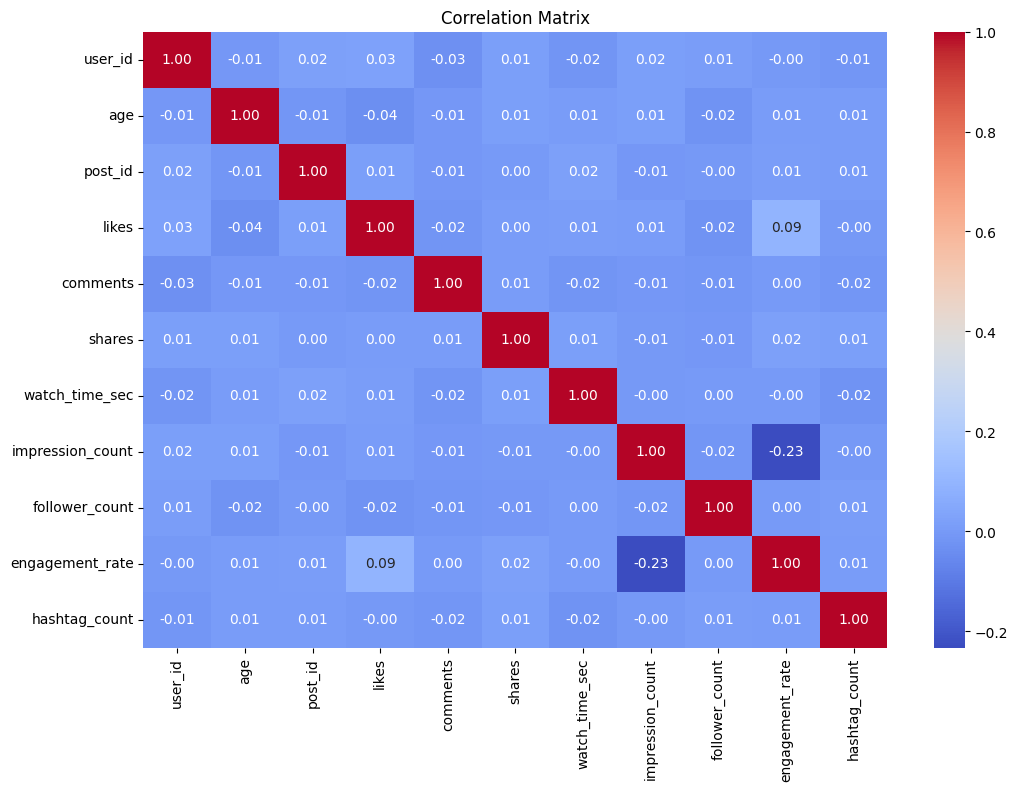

In [52]:
plt.figure(figsize=(12,8))

sns.heatmap(correlation, annot=True,cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

# 3.6 Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).

In [53]:
# Average likes by post type
df.groupby("post_type")["likes"].mean().sort_values(ascending=False)

,likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416


In [54]:
# Average engagement rate by country
df.groupby("country")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659
UK,0.850966
Japan,0.769623
Germany,0.759000
India,0.655005


In [55]:
# Average impressions by country
df.groupby("country")["impression_count"].mean().sort_values(ascending=False)

,impression_count
country,
India,52462.386916
France,51727.673387
USA,51263.872255
UK,51119.393509
Japan,49616.135593
Brazil,49193.174603
UAE,48928.413519
Canada,48703.150097
Germany,48605.406122


In [56]:
# Average likes by category
df.groupby("country")["likes"].mean().sort_values(ascending=False)

,likes
country,
France,10372.876008
Australia,10294.124746
UAE,10227.487078
Germany,10130.458163
USA,10122.361277
Japan,10088.862288
Canada,10063.066277
India,9962.468224
UK,9935.650101


# **Task 4 — Data Wrangling**



4.1 Use merge, concat, or join if combining DataFrames.

4.2 Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.

4.3 Perform groupby summaries by post_type, country, and sentiment.


# 4.1 Use merge, concat, or join if combining DataFrames.

In [57]:
df1 = df[["post_id", "post_type"]].copy()

df2 = df[["post_id", "likes", "comments", "shares"]].copy()

merged_df = pd.merge(df1, df2, on="post_id", how="inner")

merged_df.head()

,post_id,post_type,likes,comments,shares
0,496713.0,image,7011.0,354.0,1157.0
1,157326.0,reel,11750.0,2606.0,1807.0
2,109864.0,text,4862.0,344.0,955.0
3,848877.0,text,5350.0,1083.0,1049.0
4,449706.0,image,12682.0,2735.0,1300.0


# 4.2 Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.

In [58]:
# Create Engagement Score

df["engagement_score"] = (
    df["likes"] +
    df["comments"] +
    df["shares"]
)

In [59]:
# Create Log-Transformed Metrics

import numpy as np

df["log_likes"] = np.log1p(df["likes"])
df["log_comments"] = np.log1p(df["comments"])
df["log_shares"] = np.log1p(df["shares"])

In [60]:
# Create Hashtag Count

df["hashtag_count"] = df["hashtags"].fillna("").apply(
    lambda x: len(str(x).split())
)


In [61]:
# Display new fields

df[[
    "likes",
    "comments",
    "shares",
    "engagement_score",
    "log_likes",
    "log_comments",
    "log_shares",
    "hashtag_count"
]].head()

,likes,comments,shares,engagement_score,log_likes,log_comments,log_shares,hashtag_count
0,7011.0,354.0,1157.0,8522.0,8.855378,5.872118,7.054450,3
1,11750.0,2606.0,1807.0,16163.0,9.371694,7.865955,7.499977,1
2,4862.0,344.0,955.0,6161.0,8.489411,5.843544,6.862758,1
3,5350.0,1083.0,1049.0,7482.0,8.585039,6.988413,6.956545,3
4,12682.0,2735.0,1300.0,16717.0,9.448018,7.914252,7.170888,1


# 4.3 Perform groupby summaries by post_type, country, and sentiment.

In [62]:
# GroupBy Summary by Post Type

post_type_summary = df.groupby("post_type").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "engagement_rate": "mean"
}).sort_values("engagement_rate", ascending=False)

print("Post Type Summary")
display(post_type_summary)

Post Type Summary


,likes,comments,shares,engagement_rate
post_type,,,,
video,10188.600000,1479.160000,996.834286,1.122365
text,10100.148193,1499.106024,1013.989558,1.064549
image,10104.865277,1525.235766,1019.289495,0.895646
reel,10037.802416,1504.187062,982.042089,0.783047


In [63]:
# GroupBy Summary by Country

country_summary = df.groupby("country").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "impression_count": "mean",
    "engagement_rate": "mean"
}).sort_values("engagement_rate", ascending=False)

print("Country Summary")
display(country_summary)

Country Summary


,likes,comments,shares,impression_count,engagement_rate
country,,,,,
Brazil,9886.689484,1490.434524,1008.859127,49193.174603,1.540704
Australia,10294.124746,1485.803245,1029.693712,48346.383367,1.324339
France,10372.876008,1478.695565,1051.812500,51727.673387,1.146402
UAE,10227.487078,1541.214712,989.075547,48928.413519,1.112352
Canada,10063.066277,1546.582846,996.245614,48703.150097,0.916659
UK,9935.650101,1463.042596,985.681542,51119.393509,0.850966
Japan,10088.862288,1530.434322,959.351695,49616.135593,0.769623
Germany,10130.458163,1531.826531,973.379592,48605.406122,0.759000
India,9962.468224,1494.917757,1035.315888,52462.386916,0.655005


In [64]:
# GroupBy Summary by Sentiment

sentiment_summary = df.groupby("sentiment").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "impression_count": "mean",
    "engagement_rate": "mean"
}).sort_values("engagement_rate", ascending=False)

print("Sentiment Summary")
display(sentiment_summary)

Sentiment Summary


,likes,comments,shares,impression_count,engagement_rate
sentiment,,,,,
Negative,10208.096875,1516.094792,1007.307292,50191.960417,1.038486
Neutral,9923.194499,1528.404060,996.565160,49515.971185,0.991170
Positive,10180.062077,1480.650617,1005.086749,50248.107441,0.919744


# **Task 5 — Statistical Analysis**


5. Compute descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers” columns:

a. Mean, median, mode

b. Standard deviation, variance

c. Percentiles

d. (Optional) Skewness and kurtosis


In [65]:
stats_cols = [
    "likes",
    "comments",
    "shares",
    "engagement_rate"
]

stats_df = df[stats_cols]

# Mean
mean_values = stats_df.mean()

# Median
median_values = stats_df.median()

# Mode
mode_values = stats_df.mode().iloc[0]

# Standard Deviation
std_values = stats_df.std()

# Variance
variance_values = stats_df.var()

# Percentiles
percentile_25 = stats_df.quantile(0.25)
percentile_50 = stats_df.quantile(0.50)
percentile_75 = stats_df.quantile(0.75)

# Skewness
skewness_values = stats_df.skew()

# Kurtosis
kurtosis_values = stats_df.kurtosis()

# Final summary
summary = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mode": mode_values,
    "Standard Deviation": std_values,
    "Variance": variance_values,
    "25%": percentile_25,
    "50%": percentile_50,
    "75%": percentile_75,
    "Skewness": skewness_values,
    "Kurtosis": kurtosis_values
})

summary.T

,likes,comments,shares,engagement_rate
Mean,1.010700e+04,1502.039800,1002.910600,0.964356
Median,1.010550e+04,1497.000000,1012.000000,0.253896
Mode,1.010550e+04,1497.000000,1012.000000,0.006363
Standard Deviation,5.702293e+03,856.393312,570.855200,5.318029
Variance,3.251615e+07,733409.504917,325875.659340,28.281435
25%,5.235000e+03,792.000000,511.000000,0.145781
50%,1.010550e+04,1497.000000,1012.000000,0.253896
75%,1.495900e+04,2235.250000,1483.000000,0.504794
Skewness,-6.893617e-03,0.003802,-0.014654,18.781271
Kurtosis,-1.149992e+00,-1.144375,-1.146857,482.991739


# **Task 6 — Data Visualization**

**6.1 Matplotlib**

○ Scatter: likes vs impressions

○ Line: daily engagement trend

○ Bar: posts by category

○ Pie: gender distribution

○ Histogram: age

○ Box: engagement rate


# 1. Scatter: likes vs impressions

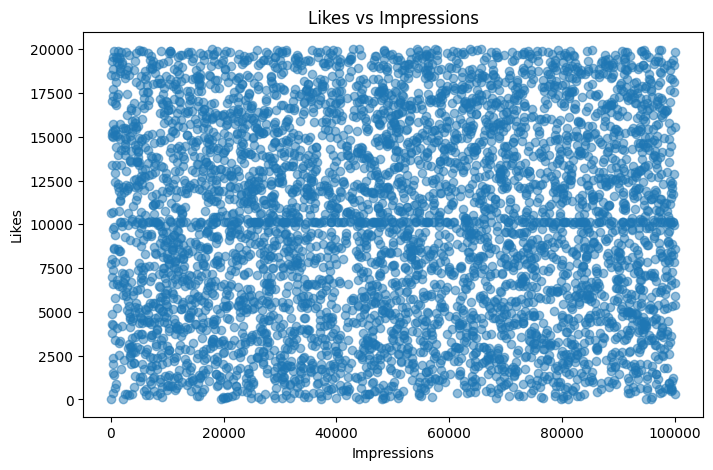

In [66]:
plt.figure(figsize=(8, 5))

plt.scatter(df["impression_count"], df["likes"], alpha=0.5)

plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.title("Likes vs Impressions")

plt.show()



# Plot 2 — Line Chart: Daily Engagement Trend

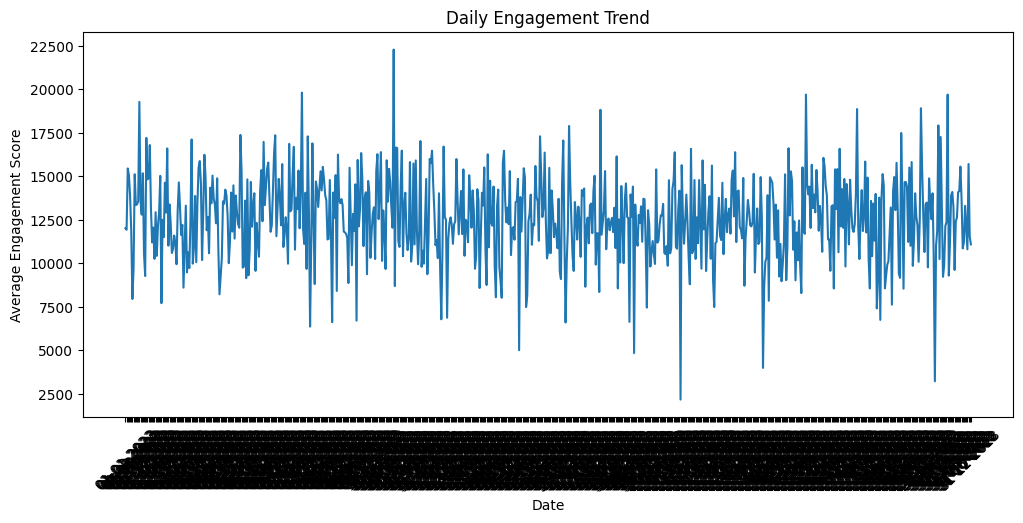

In [67]:
daily_engagement = df.groupby("posted_at")["engagement_score"].mean()

plt.figure(figsize=(12, 5))

plt.plot(daily_engagement.index, daily_engagement.values)

plt.xlabel("Date")
plt.ylabel("Average Engagement Score")
plt.title("Daily Engagement Trend")

plt.xticks(rotation=45)
plt.show()


# Plot 3 — Bar Chart: Posts by Category

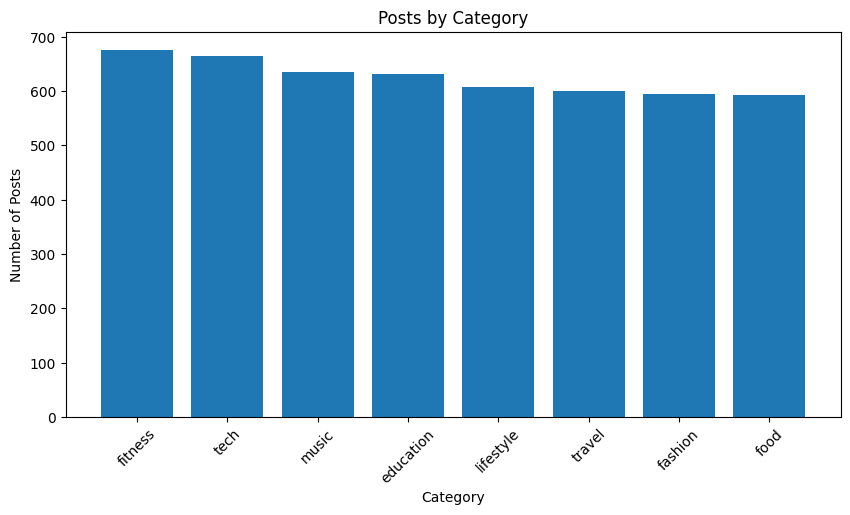

In [68]:
category_counts = df["post_category"].value_counts()

plt.figure(figsize=(10, 5))

plt.bar(category_counts.index, category_counts.values)

plt.xlabel("Category")
plt.ylabel("Number of Posts")
plt.title("Posts by Category")

plt.xticks(rotation=45)
plt.show()


# Plot 4 — Pie Chart: Gender Distribution

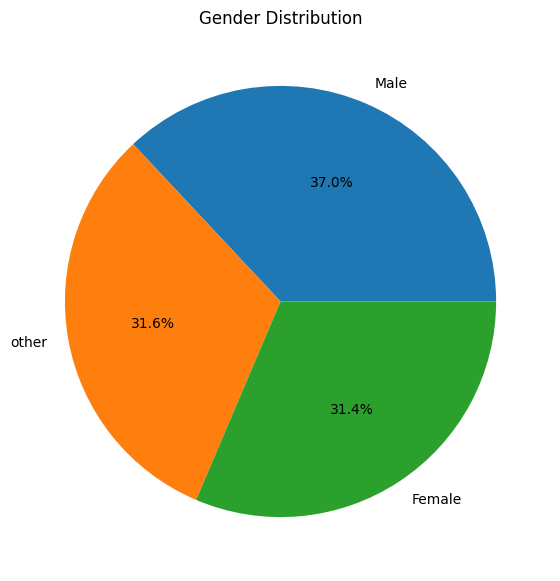

In [69]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.show()


# Plot 5 — Histogram: Age

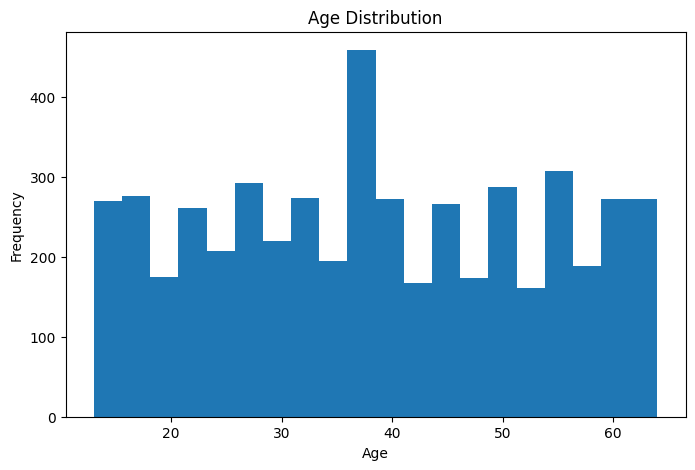

In [70]:
plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=20)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()


# Plot 6 — Box Plot: Engagement Rate

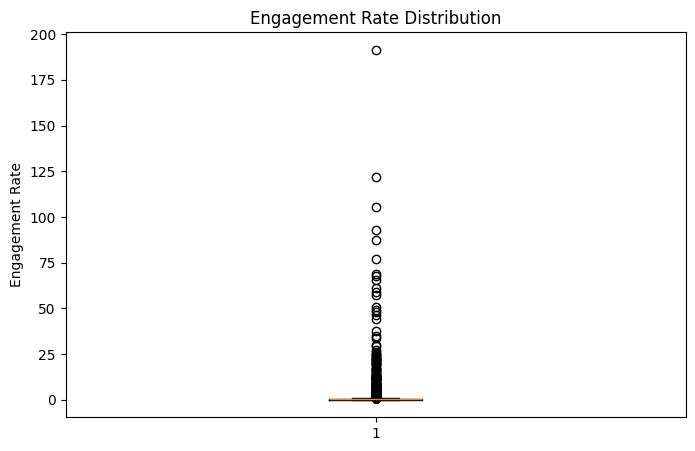

In [71]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["engagement_rate"].dropna())

plt.ylabel("Engagement Rate")
plt.title("Engagement Rate Distribution")

plt.show()


# **Seaborn Visualizations**



# Plot 7 — Count Plot: Post Type

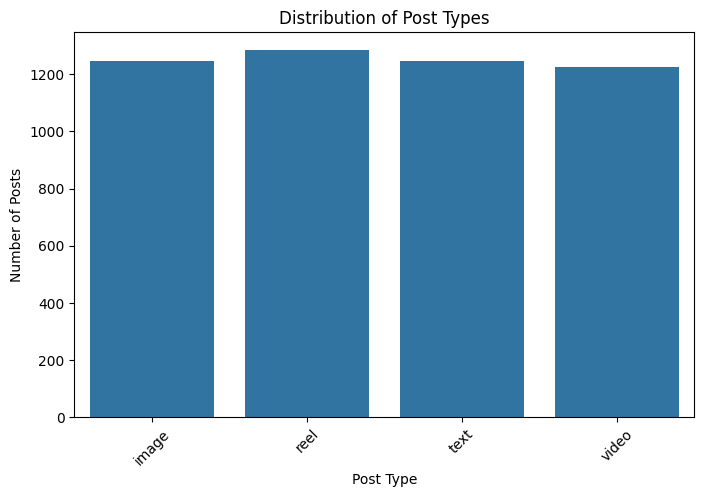

In [72]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="post_type")

plt.title("Distribution of Post Types")
plt.xlabel("Post Type")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)
plt.show()


# Plot 8 — Bar Plot: Average Likes by Category

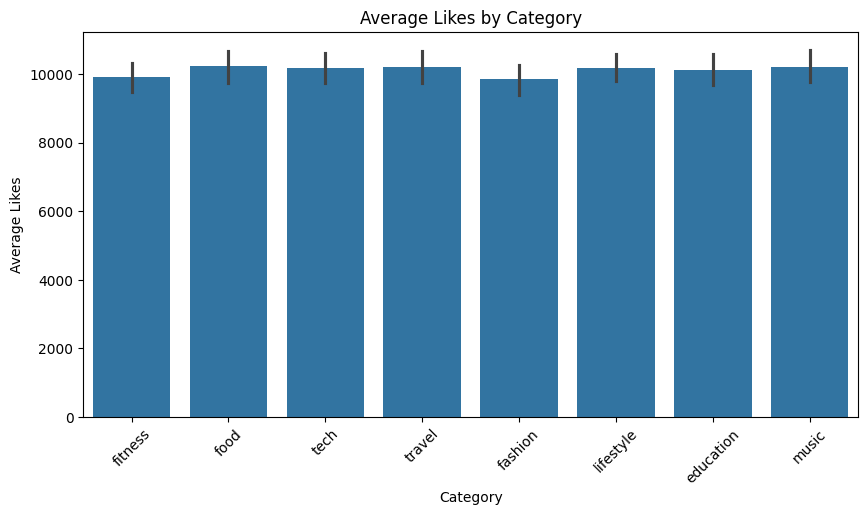

In [73]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="post_category",
    y="likes",
    estimator="mean"
)

plt.title("Average Likes by Category")
plt.xlabel("Category")
plt.ylabel("Average Likes")
plt.xticks(rotation=45)
plt.show()


# Plot 9 — Violin Plot: Followers vs Sentiment

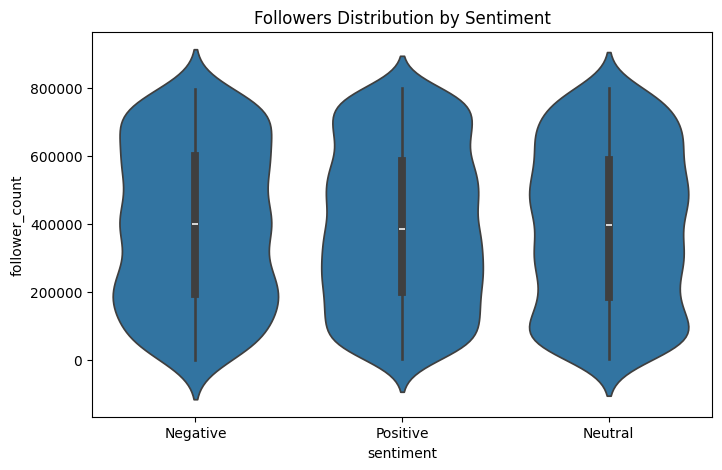

In [74]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count"
)

plt.title("Followers Distribution by Sentiment")
plt.show()


# Plot 10 — Pair Plot

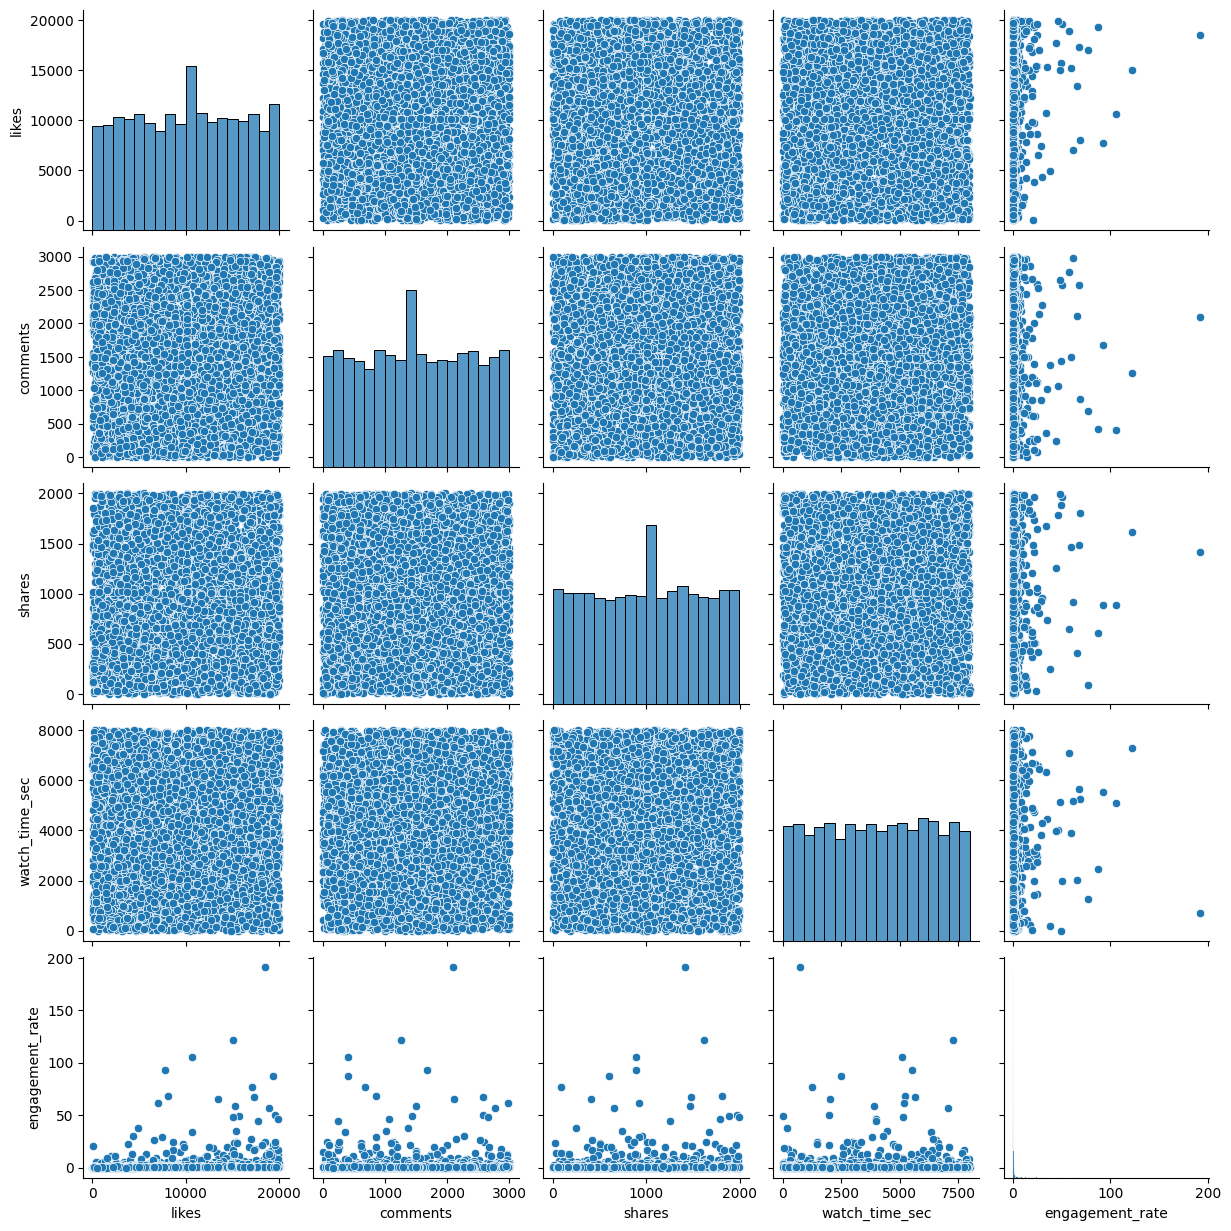

In [75]:
pair_cols = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate"
]

sns.pairplot(df[pair_cols].dropna())

plt.show()


# Plot 11 — Heatmap

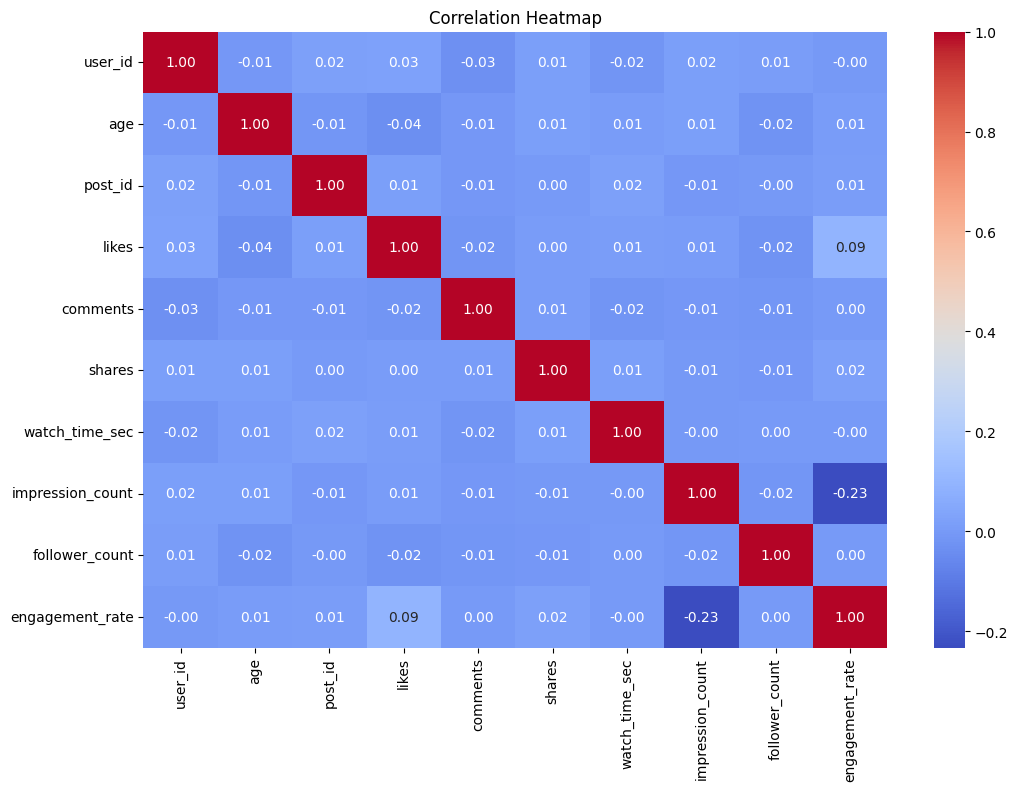

In [76]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_colm].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


## Plot 12 — Swarm Plot: Engagement vs Device

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 16.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 14.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 16.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


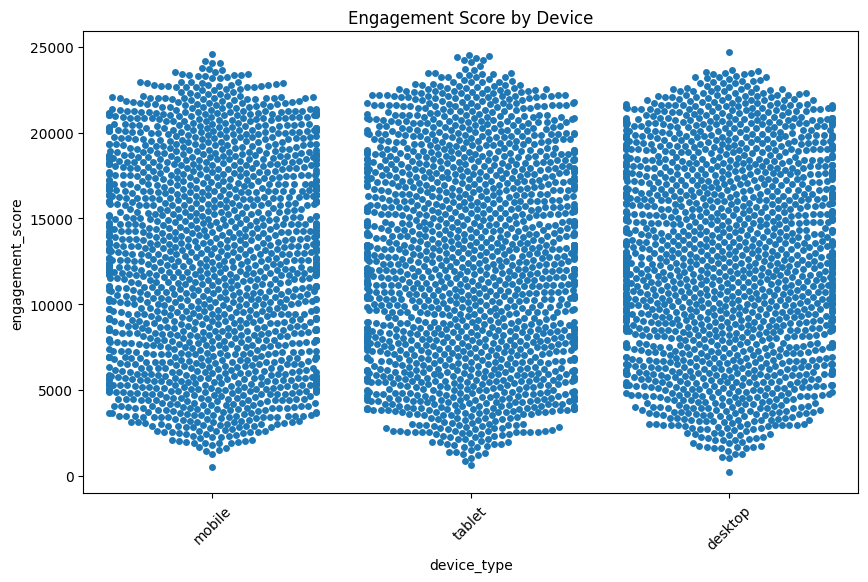

In [77]:
plt.figure(figsize=(10, 6))

sns.swarmplot(
    data=df,
    x="device_type",
    y="engagement_score"
)

plt.title("Engagement Score by Device")
plt.xticks(rotation=45)

plt.show()


# **Plotly Interactive Visualization**

# Interactive Line Chart

In [78]:
import plotly.express as px

daily_engagement = df.groupby("posted_at",as_index=False)["engagement_rate"].mean()

fig = px.line(
    daily_engagement,
    x="posted_at",
    y="engagement_rate",
    title="Daily Engagement Trend"
)

fig.show()

# **Final Insights**



# **a.Content Performance**

1. Which post types have the highest engagement?

2. Best-performing content category?

3. Which countries have the highest average engagement rate?





In [79]:
# Post type with highest engagement
post_type_engagement = (
    df.groupby("post_type")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

print(post_type_engagement)
print("Highest:", post_type_engagement.index[0])

post_type
video    1.122365
text     1.064549
image    0.895646
reel     0.783047
Name: engagement_rate, dtype: float64
Highest: video


In [80]:
# Best-performing category
category_engagement = (
    df.groupby("post_category")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

print(category_engagement)
print("Highest:", category_engagement.index[0])

post_category
food         1.358628
tech         1.160475
lifestyle    1.091019
music        0.888803
fitness      0.865628
education    0.844222
fashion      0.807109
travel       0.702223
Name: engagement_rate, dtype: float64
Highest: food


In [81]:
# Countries with highest average engagement
country_engagement = (
    df.groupby("country")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

print(country_engagement.head(10))

country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
UK           0.850966
Japan        0.769623
Germany      0.759000
India        0.655005
USA          0.576580
Name: engagement_rate, dtype: float64


# **b.User Trends**

1. How age affects engagement

2. Performance difference for verified accounts

age_group
Below 18    0.867038
18-25       1.059536
26-35       0.865316
36-45       0.860741
46-55       1.414058
56+         0.709213
Name: engagement_rate, dtype: float64


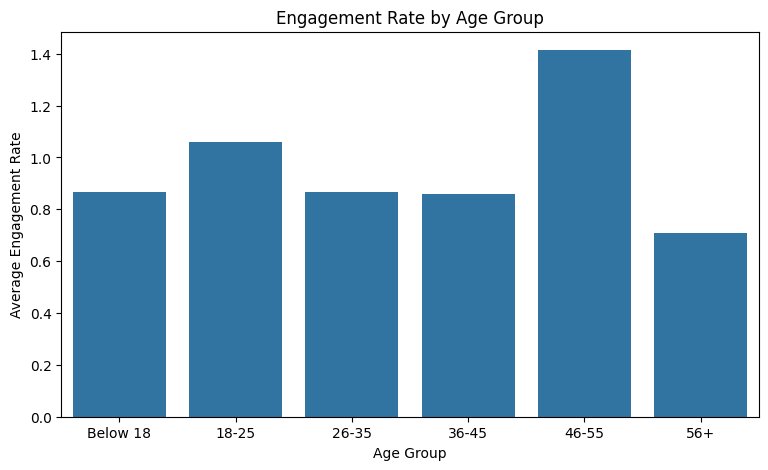

In [82]:
# Age vs Engagement
# Create age groups:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 25, 35, 45, 55, 100],
    labels=[
        "Below 18",
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56+"
    ]
)

age_engagement = df.groupby("age_group", observed=False)["engagement_rate"].mean()

print(age_engagement)
# Visualization:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_engagement.index,
    y=age_engagement.values
)

plt.xlabel("Age Group")
plt.ylabel("Average Engagement Rate")
plt.title("Engagement Rate by Age Group")

plt.show()


In [83]:
# Verified vs Non-Verified Accounts

df["follower_count"].value_counts()

verified_analysis = df.groupby("follower_count").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "engagement_rate": "mean",
    "follower_count": "mean"
})

verified_analysis


,likes,comments,shares,engagement_rate,follower_count
follower_count,,,,,
87.0,9927.0,2116.0,70.0,0.154518,87.0
498.0,3874.0,847.0,1837.0,0.120642,498.0
624.0,1141.0,1128.0,270.0,0.026701,624.0
922.0,4687.0,2420.0,1776.0,0.110994,922.0
1332.0,8513.0,2775.0,247.0,0.211717,1332.0
...,...,...,...,...,...
798949.0,14373.0,1698.0,488.0,0.302276,798949.0
799076.0,10443.0,2919.0,109.0,0.715667,799076.0
799416.0,3365.0,783.0,265.0,5.523154,799416.0


# **c.Behavioral Insights**

1. Best time of day for impressions

2. Device type impact on watch time

In [88]:
# c. Behavioral Insights

# 1. Best time of day for impressions

df["watch_time_sec"] = pd.to_datetime(df["posted_at"]).dt.hour

hourly_impressions = (
    df.groupby("watch_time_sec")["impression_count"]
    .mean()
    .sort_values(ascending=False)
)

print("Average impressions by hour:")
print(hourly_impressions)

print(
    "Highest average impressions hour:",
    hourly_impressions.index[0]
)


# 2. Device type impact on watch time

device_watch_time = (
    df.groupby("device_type")["watch_time_sec"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage watch time by device:")
print(device_watch_time)

print(
    "Device with highest average watch time:",
    device_watch_time.index[0]
)


Average impressions by hour:
watch_time_sec
0    50013.7328
Name: impression_count, dtype: float64
Highest average impressions hour: 0

Average watch time by device:
device_type
desktop    0.0
mobile     0.0
tablet     0.0
Name: watch_time_sec, dtype: float64
Device with highest average watch time: desktop


/tmp/ipykernel_2411/2976842995.py:5: UserWarning:

Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



In [89]:
import matplotlib.pyplot as plt
device_watch = (
    df.groupby("device_type")["watch_time_sec"]
    .mean()
    .sort_values(ascending=False)
)

print(device_watch)


device_type
desktop    0.0
mobile     0.0
tablet     0.0
Name: watch_time_sec, dtype: float64


# **d. Sentiment Analysis**

1. Which sentiment performs best

2. Behavior of negative/neutral sentiment posts

In [90]:
# Which sentiment performs best?
sentiment_performance = (
    df.groupby("sentiment").agg({
        "likes": "mean",
        "comments": "mean",
        "shares": "mean",
        "engagement_rate": "mean",
        "impression_count": "mean"
    })
)

sentiment_performance
# You can specifically compare:
sentiment_engagement = (
    df.groupby("sentiment")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

print(sentiment_engagement)


sentiment
Negative    1.038486
Neutral     0.991170
Positive    0.919744
Name: engagement_rate, dtype: float64


In [91]:
# Negative vs Neutral Sentiment Behavior
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()

negative_neutral = df[
    df["sentiment"].isin(["negative", "neutral"])
]

sentiment_behavior = negative_neutral.groupby("sentiment").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "impression_count": "mean",
    "engagement_rate": "mean"
}).round(2)

sentiment_behavior

,likes,comments,shares,impression_count,engagement_rate
sentiment,,,,,
negative,10208.10,1516.09,1007.31,50191.96,1.04
neutral,9923.19,1528.40,996.57,49515.97,0.99
